In [3]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# import numerical integration
from scipy.integrate import cumulative_trapezoid

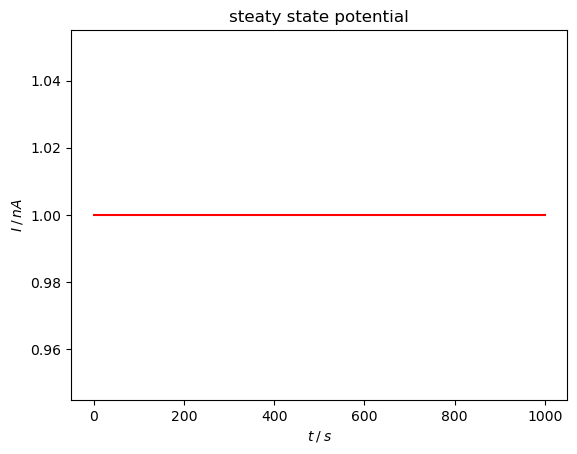

In [5]:
# load csv values
df = pd.read_csv('Testfile_1.csv')
plt.plot(df['t'],df['I'],'r')
plt.ylabel('$I\: / \:nA$')
plt.xlabel('$t\: / \:s$')
plt.title('steaty state potential')
plt.show()

In [6]:
def G1_Semiint1(I,t):
    # (equidistant) time step
    delta = t[1]-t[0]
    # No. of steps
    N_max = I.size
    # initialize with zeros
    G1 = np.zeros(N_max)

    sqr_d = np.sqrt(delta)
    
    for N in range(1,N_max+1):
        # value for n = N with w0 = 1
        G1_i = I[0]; 
        #      go from N to 0
        for n in range(N-1,0,-1):
            G1_i = G1_i*(1-(0.5)/n) + I[N-n]
            
        G1[N-1] = G1_i*sqr_d
    return(G1)

In [7]:
# example of allclosure
rtol=1e-07
atol=1e-06

a = [1e10,1e-6]
b = [1.00001e10,1e-9]
 


#print(np.allclose(a, b,rtol=0.01,atol=0.1))
print('val', np.abs(np.subtract(a,b)))
print('ref',(atol + rtol * np.abs(b)))
test = np.abs(np.subtract(a,b)) <= (atol + rtol * np.abs(b))
print(test)
print(all(test))

np.allclose(a, b,rtol=rtol, atol=atol)

val [1.00e+05 9.99e-07]
ref [1.00001e+03 1.00000e-06]
[False  True]
False


False

In [8]:
# load testvalues
df = pd.read_csv('Testfile_2.csv')

rtol = 1e-2
# allclosed
Case1 = np.allclose(G1_Semiint1(G1_Semiint1(df['I'],df['t']), df['t'])[:-1], cumulative_trapezoid(df['I'],df['t']), rtol=rtol)

# manual
df1 = G1_Semiint1(G1_Semiint1(df['I'],df['t']), df['t'])
df2 = cumulative_trapezoid(df['I'],df['t'])

df1= df1[:-1]
error = (np.abs(df1 - df2))
rel_err= error/(np.abs(df2))
Case2 = np.allclose(df1, df2, rtol=rtol)

print('      G1 values:',df1[0:4])
print('cum trap values:',df2[0:4],'\n')

print('maximum error')
print(max(error))

print('relative error')
print(max(rel_err))


print('allclose', Case1)
print('manuel  ',Case2)

      G1 values: [3.60363364e-06 7.27807969e-06 1.10247295e-05 1.48450019e-05]
cum trap values: [3.63903985e-06 7.34958779e-06 1.11330489e-05 1.49908559e-05] 

maximum error
0.030308122017924433
relative error
0.00972954502495288
allclose True
manuel   True


In [9]:
# Test run
mysize = 1000
x = np.linspace(0,1000, mysize)
y = np.array([1]*mysize)

d1 = G1_Semiint1(G1_Semiint1(y,x), x)
d2 = cumulative_trapezoid(y,x)

#d1[0]= 1.002
d1= d1[:-1]

print('      G1 values:',d1[0:4])
print('cum trap values:',d2[0:4],'\n')


error = (np.abs(d1 - d2))
rel_err= error/(np.abs(d2))

print('maximum error')
print(max(error))

print('relative error')
print(max(rel_err))

Case =np.allclose(d1, d2, rtol=1e-4)

#Case =np.allclose(G1_Semiint1(G1_Semiint1(y,x), x)[:-1], cumulative_trapezoid(y,x), atol=2e-10)

print(Case)



      G1 values: [1.001001 2.002002 3.003003 4.004004]
cum trap values: [1.001001 2.002002 3.003003 4.004004] 

maximum error
3.183231456205249e-12
relative error
3.4262291328102225e-15
True


In [10]:
# Python program explaining
# allclose() function
  
import numpy as np
  
# input arrays
in_arr1 = np.array([5e5, 1e-7, 4.00004e6])
print ("1st Input array : ", in_arr1) 
  
in_arr2 = np.array([5.00001e5, 1e-7, 4e6])
print ("2nd Input array : ", in_arr2) 
  
# setting the absolute and relative tolerance
rtol = 1e-05

res = np.allclose(in_arr1, in_arr2, rtol)
print ("Are the two arrays are equal within the tolerance: \t", res)


1st Input array :  [5.00000e+05 1.00000e-07 4.00004e+06]
2nd Input array :  [5.00001e+05 1.00000e-07 4.00000e+06]
Are the two arrays are equal within the tolerance: 	 True


In [11]:
def prepare_kernel(q, delta_x, N, c1, c2):
    """
    Setup the integration kernel with the order q, the x interval delat_x, the length of the array N,
    and the filter constants c1 and c2.
    """
    tau0 = delta_x * N**0.5
    a0 = np.sin(np.pi * q) / (np.pi * q * tau0**q)
    # total number of filters
    n_filters = 2 * c1 * c2 + 1
    # dimension according to the number of filters
    # filter weights
    w1 = np.zeros(n_filters)
    w2 = np.zeros(n_filters)
    # auxiliary array
    s = np.zeros(n_filters)

    for i in range(2 * c1 * c2):
        j = i - c1 * c2
        a_j = (a0 / c2) * np.exp(j / c2)
        t_j = tau0 * np.exp(-j / (q * c2))
        w1[i] = t_j / (delta_x + t_j)
        w2[i] = a_j * (1 - w1[i])
    return s, w1, w2


def semi_integration(y, q=-0.5, delta_x=1, c1=8, c2=2):
    """
    Return the semiintegral R of order q for y with the x interval delta_x and the filter constants
    c1 and c2.

    Semi-integrating two times with order q = -0.5 should give the same result as integrating once.
    The relative error should not exceed 0.25 percent for 1000 and 0.5 percent per 10000 integration steps.
    TODO:: see #6
    - add test for non constant y values

    TEST:
    >>> from scipy.integrate import cumulative_trapezoid
    >>> x = np.linspace(0,1000, 1001)
    >>> delta_x = x[1] - x[0]
    >>> y = np.array([1]*1001)
    >>> np.allclose(semi_integration(semi_integration(y, delta_x=delta_x), delta_x=delta_x), cumulative_trapezoid(y,x,initial=0), rtol=2.5e-03)
    True
    >>> x = np.linspace(0,1000, 10001)
    >>> delta_x = x[1] - x[0]
    >>> y = np.array([1]*10001)
    >>> np.allclose(semi_integration(semi_integration(y, delta_x=delta_x), delta_x=delta_x), cumulative_trapezoid(y,x,initial=0), rtol=5e-03)
    True
    >>> import pandas as pd
    >>> df2 = pd.read_csv('TestFiles/Testfile_2.csv')
    >>> delta_x = df2['t'][1] - df2['t'][0]
    >>> np.allclose(semi_integration(semi_integration(df2['I'],delta_x=delta_x),delta_x=delta_x), cumulative_trapezoid(df2['I'],delta_x=delta_x), rtol=1e-0)
    True
    """

    N = y.size
    R = np.zeros(N)
    s, w1, w2 = prepare_kernel(q, delta_x, N, c1, c2)
    for k in range(1, N):
        for i in range(s.size):
            s[i] = s[i] * w1[i] + y[k] * w2[i]
            R[k] = R[k] + s[i]
    return R


In [12]:
x = np.linspace(0,1000, 10001)
delta_x = x[1] - x[0]
y = np.array([1]*10001)
Case = np.allclose(semi_integration(semi_integration(y, delta_x=delta_x), delta_x=delta_x), cumulative_trapezoid(y,x,initial=0), rtol=5e-03)
print(Case)

True


In [21]:
df2 = pd.read_csv('Testfile_2.csv')
delta_x = df2['t'][1] - df2['t'][0]
Case = np.allclose(semi_integration(semi_integration(df2['I'],delta_x=delta_x),delta_x=delta_x)[:-1], cumulative_trapezoid(df2['I'],df2['t']), rtol=1e-1)
print(Case)

False
